In [1]:
import os
import glob
import json
import itertools
import numpy as np
import pandas as pd
from pathlib import Path
from PNW_cmap import PNW_cmap
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from vip_slap2_analysis.utils.utils import save_figure
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.glutamate.summary import GlutamateSummary
from vip_slap2_analysis.utils.utils import normalize
from vip_slap2_analysis.glutamate.analysis import (
    GlutamateAnalysisConfig,
    run_glutamate_tuning_analysis,
)

import seaborn as sns
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))



In [2]:
%load_ext autoreload
%autoreload 2

%matplotlib notebook

In [3]:
savepath = r'C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Data_Club\April2026\figures'

In [4]:
target_mice = [
    803496,
    804730,804733,810196,
    809047,803121,
    826033,838410,834788
]

registry = VIPSessionRegistry.from_basepath(
    r'\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics'
)

process_df = registry.sessions(
    subject_ids=target_mice,
    exclude_session_types=["expression_check", "volume_imaging"],
    paradigms=["change_detection_passive"],
)

assets = [registry.resolve_assets(row) for _, row in process_df.iterrows()]

print(f"Loaded {len(assets)} session assets")

Loaded 56 session assets


In [5]:
st_paths = [glob.glob(os.path.join(asset.derived_dir,'**','glutamate_single_trial_df.npz'),recursive=True)[0] for asset in assets]

In [6]:
act_summary_path = r"C:\Users\andrew.shelton\Downloads\activation_summary.csv"
act_summary = pd.read_csv(act_summary_path)

In [25]:
config = GlutamateAnalysisConfig(
    tuning_method="fve",
    tuning_fve_mode="trace",                 # "trace" = no time averaging
    tuning_fve_amplitude_func="mean",        # mainly relevant for time_avg mode
    tuning_fve_sample_slice=(50, 100),       # mainly relevant for time_avg mode
    tuning_response_classes=("activated",'deactivated','no_change'),  # note trailing comma
    n_shuffles_tuning=10,                    # keep low while testing
    random_seed=0,
)

In [26]:
all_tuning_summary = []
all_tuning_per_image = []

for asset in assets:
    print(asset.session_id)
    session_root = asset.session_dir

    results = run_glutamate_tuning_analysis(
        session_dir_or_analysis_dir=session_root,
        activation_summary=act_summary_path,   # or activation_summary_df
        config=config,
        save_tables=False,
    )

    tuning_summary = results["tuning_summary_table"].copy()
    tuning_per_image = results["tuning_per_image_table"].copy()

    dmd_depth_map = {
        "DMD1": asset.metadata.get("dmd1_depth", np.nan),
        "DMD2": asset.metadata.get("dmd2_depth", np.nan),
    }

    if not tuning_summary.empty and "dmd" in tuning_summary.columns:
        tuning_summary["depth"] = tuning_summary["dmd"].map(dmd_depth_map)
        tuning_summary["session_name"] = os.path.basename(session_root)
        all_tuning_summary.append(tuning_summary)
    else:
        print(f"No tuning summary rows for {session_root}")

    if not tuning_per_image.empty and "dmd" in tuning_per_image.columns:
        tuning_per_image["depth"] = tuning_per_image["dmd"].map(dmd_depth_map)
        tuning_per_image["session_name"] = os.path.basename(session_root)
        all_tuning_per_image.append(tuning_per_image)
    else:
        print(f"No tuning per-image rows for {session_root}")

tuning_summary_table = pd.concat(all_tuning_summary, ignore_index=True) if all_tuning_summary else pd.DataFrame()
tuning_per_image_table = pd.concat(all_tuning_per_image, ignore_index=True) if all_tuning_per_image else pd.DataFrame()

803496_2025-07-25_13-02-10
803496_2025-07-28_08-04-39


C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis\src\vip_slap2_analysis\glutamate\analysis.py:447: RuntimeWarning: Mean of empty slice
  return np.nanmean(arr, axis=1)
C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis\src\vip_slap2_analysis\glutamate\analysis.py:447: RuntimeWarning: Mean of empty slice
  return np.nanmean(arr, axis=1)
C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis\src\vip_slap2_analysis\glutamate\analysis.py:447: RuntimeWarning: Mean of empty slice
  return np.nanmean(arr, axis=1)
C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis\src\vip_slap2_analysis\glutamate\analysis.py:447: RuntimeWarning: Mean of empty slice
  return np.nanmean(arr, axis=1)
C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis\src\vip_slap2_analysis\glutamate\analysis.py:447: RuntimeWarning: Mean of empty

C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis\src\vip_slap2_analysis\glutamate\analysis.py:447: RuntimeWarning: Mean of empty slice
  return np.nanmean(arr, axis=1)
C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis\src\vip_slap2_analysis\glutamate\analysis.py:447: RuntimeWarning: Mean of empty slice
  return np.nanmean(arr, axis=1)
C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis\src\vip_slap2_analysis\glutamate\analysis.py:447: RuntimeWarning: Mean of empty slice
  return np.nanmean(arr, axis=1)
C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis\src\vip_slap2_analysis\glutamate\analysis.py:447: RuntimeWarning: Mean of empty slice
  return np.nanmean(arr, axis=1)
C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis\src\vip_slap2_analysis\glutamate\analysis.py:447: RuntimeWarning: Mean of empty

803496_2025-07-29_13-34-35
803496_2025-07-30_10-05-23
803496_2025-07-31_09-43-28
803496_2025-08-01_13-22-49


C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis\src\vip_slap2_analysis\glutamate\analysis.py:447: RuntimeWarning: Mean of empty slice
  return np.nanmean(arr, axis=1)
C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis\src\vip_slap2_analysis\glutamate\analysis.py:447: RuntimeWarning: Mean of empty slice
  return np.nanmean(arr, axis=1)
C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis\src\vip_slap2_analysis\glutamate\analysis.py:447: RuntimeWarning: Mean of empty slice
  return np.nanmean(arr, axis=1)
C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis\src\vip_slap2_analysis\glutamate\analysis.py:447: RuntimeWarning: Mean of empty slice
  return np.nanmean(arr, axis=1)
C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis\src\vip_slap2_analysis\glutamate\analysis.py:447: RuntimeWarning: Mean of empty

...

838410_2026-03-20_10-00-59


C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis\src\vip_slap2_analysis\glutamate\analysis.py:447: RuntimeWarning: Mean of empty slice
  return np.nanmean(arr, axis=1)
C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis\src\vip_slap2_analysis\glutamate\analysis.py:447: RuntimeWarning: Mean of empty slice
  return np.nanmean(arr, axis=1)
C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis\src\vip_slap2_analysis\glutamate\analysis.py:447: RuntimeWarning: Mean of empty slice
  return np.nanmean(arr, axis=1)
C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis\src\vip_slap2_analysis\glutamate\analysis.py:447: RuntimeWarning: Mean of empty slice
  return np.nanmean(arr, axis=1)
C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis\src\vip_slap2_analysis\glutamate\analysis.py:447: RuntimeWarning: Mean of empty

C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis\src\vip_slap2_analysis\glutamate\analysis.py:447: RuntimeWarning: Mean of empty slice
  return np.nanmean(arr, axis=1)
C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis\src\vip_slap2_analysis\glutamate\analysis.py:447: RuntimeWarning: Mean of empty slice
  return np.nanmean(arr, axis=1)
C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis\src\vip_slap2_analysis\glutamate\analysis.py:447: RuntimeWarning: Mean of empty slice
  return np.nanmean(arr, axis=1)
C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis\src\vip_slap2_analysis\glutamate\analysis.py:447: RuntimeWarning: Mean of empty slice
  return np.nanmean(arr, axis=1)
C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis\src\vip_slap2_analysis\glutamate\analysis.py:447: RuntimeWarning: Mean of empty

C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis\src\vip_slap2_analysis\glutamate\analysis.py:447: RuntimeWarning: Mean of empty slice
  return np.nanmean(arr, axis=1)
C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis\src\vip_slap2_analysis\glutamate\analysis.py:447: RuntimeWarning: Mean of empty slice
  return np.nanmean(arr, axis=1)
C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis\src\vip_slap2_analysis\glutamate\analysis.py:447: RuntimeWarning: Mean of empty slice
  return np.nanmean(arr, axis=1)
C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis\src\vip_slap2_analysis\glutamate\analysis.py:447: RuntimeWarning: Mean of empty slice
  return np.nanmean(arr, axis=1)
C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis\src\vip_slap2_analysis\glutamate\analysis.py:447: RuntimeWarning: Mean of empty

C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis\src\vip_slap2_analysis\glutamate\analysis.py:447: RuntimeWarning: Mean of empty slice
  return np.nanmean(arr, axis=1)
C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis\src\vip_slap2_analysis\glutamate\analysis.py:447: RuntimeWarning: Mean of empty slice
  return np.nanmean(arr, axis=1)
C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis\src\vip_slap2_analysis\glutamate\analysis.py:447: RuntimeWarning: Mean of empty slice
  return np.nanmean(arr, axis=1)
C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis\src\vip_slap2_analysis\glutamate\analysis.py:447: RuntimeWarning: Mean of empty slice
  return np.nanmean(arr, axis=1)
C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis\src\vip_slap2_analysis\glutamate\analysis.py:447: RuntimeWarning: Mean of empty

In [14]:
tuning_summary_table.keys()

Index(['session_id', 'subject_id', 'dmd', 'synapse_id', 'response_class',
       'n_image_trials', 'n_images_tested', 'fve_image', 'total_var',
       'mean_residual_var', 'mean_fve', 'image_residual_var', 'fve_mode',
       'fve_amplitude_func', 'fve_sample_start', 'fve_sample_stop',
       'p_shuffle_fve', 'p_kw', 'p_manova', 'f_manova', 'stat_value_manova',
       'num_df_manova', 'den_df_manova', 'n_trials_manova', 'n_groups_manova',
       'n_timepoints_used_manova', 'manova_stat_used', 'preferred_image',
       'preferred_mean', 'preferred_median', 'preferred_vs_rest_effect',
       'preferred_vs_next_effect', 'is_tuned', 'tuning_method', 'depth',
       'session_name'],
      dtype='object')

In [27]:
plot_df = tuning_summary_table.copy()

In [28]:
cl, cmap, cp = PNW_cmap.get_PNW_cmap('Sailboat', n_colors=4)
cp

[(0.4823529411764706, 0.7372549019607844, 0.8352941176470589),
 (0.8156862745098039, 0.8862745098039215, 0.6862745098039216),
 (0.9607843137254901, 0.8588235294117647, 0.6),
 (0.9098039215686274, 0.611764705882353, 0.5058823529411764)]

In [29]:
cp = cp[::-1]

<IPython.core.display.Javascript object>


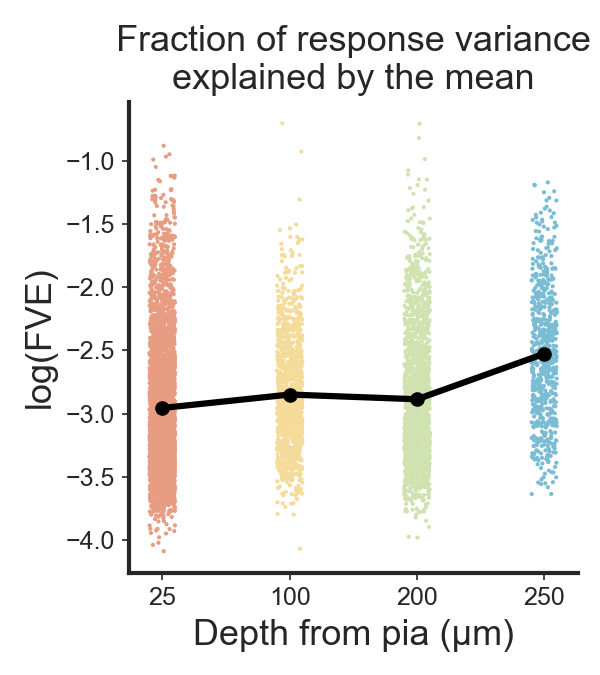

C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_28436\548872126.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data = plot_df,x = 'depth', y = np.log10(plot_df[metric]),palette=cp,size=2)


In [39]:
metric = 'mean_fve'

fig,ax=plt.subplots(figsize=(4,4.5))

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

for spine in ['left','right','top','bottom']:
    ax.spines[spine].set_linewidth(2)

sns.despine()
    
sns.stripplot(data = plot_df,x = 'depth', y = np.log10(plot_df[metric]),palette=cp,size=2)

means = []

for depth in plot_df['depth'].unique():
    dft = plot_df[plot_df['depth']==depth]
    mean = np.nanmean(np.log10(dft[metric]))
    means.append(mean)
ax.plot(means,color='k',zorder=11,lw=3,marker='o')
# ax.set_ylim(-3.75,0.75)

ax.set_ylabel('log(FVE)')
ax.set_xlabel('Depth from pia (\u03BCm)')

ax.set_title('Fraction of response variance\nexplained by the mean')

fig.tight_layout()
filen = 'Image_FVE'
# save_figure(fig,os.path.join(savepath,filen),formats = ['.pdf','.png'],dpi= 300)